<a href="https://colab.research.google.com/github/shampharma05/acinetobacter-colistin-resistance-india/blob/main/Acinetobacter_Colistin_Resistance_India_2018_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Colistin Resistance in *Acinetobacter* spp. in India (2018–2023)

## Project objective

This project analyses reported colistin resistance in *Acinetobacter* spp. bloodstream infections in India from 2018 to 2023 using antimicrobial resistance surveillance data.

The objectives are to:
- Examine yearly reported resistance percentages in India.
- Compare India's reported resistance trend with the global median.
- Explore the global antibiotic resistance profile for *Acinetobacter* spp. bloodstream infections in 2023.

**Tools:** Python, Pandas, Matplotlib

**Analysis type:** Secondary data analysis

## Data and methodology

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
file_2023 = pd.read_csv(
    "/content/Resistance to antibiotics in 2023_All-Bloodstream.csv",
    skiprows=6
)

file_2023.head()

,Specimen,PathogenName,AntibioticName,Min,Q1,Median,Q3,Max,CTAsCount,TotalBCIsWithAST
0,Bloodstream,Acinetobacter spp.,Amikacin,0,10.843373494,44.206773619,70.476190476,94.418604651,77,43102
1,Bloodstream,Acinetobacter spp.,Colistin,0,0.978606393,3.851851852,8.26317716,47.540983607,46,15553
2,Bloodstream,Acinetobacter spp.,Doripenem,14.814814815,33.703703704,48.794642857,59.007513066,63.262195122,4,994
3,Bloodstream,Acinetobacter spp.,Gentamicin,0,27.698863636,54.435288415,67.289229751,96.875,83,44185
4,Bloodstream,Acinetobacter spp.,Imipenem,0,31.325301205,65.330188679,81.818181818,100,73,42540


In [ ]:
country_data = pd.read_csv(
    "/content/Time series of resistance to antibiotics (2018-2023)_All-BLOOD.csv",
    skiprows=17
)

country_data.head()

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
0,ARG,Argentina,Region of the Americas,2018,BLOOD,Acinetobacter spp.,Colistin,7385,352,9,2.556818
1,BIH,Bosnia and Herzegovina,European Region,2018,BLOOD,Acinetobacter spp.,Colistin,841,63,3,4.761905
2,IND,India,South-East Asia Region,2018,BLOOD,Acinetobacter spp.,Colistin,14459,42,0,0.000000
3,IRN,Iran (Islamic Republic of),Eastern Mediterranean Region,2018,BLOOD,Acinetobacter spp.,Colistin,1826,246,20,8.130081
4,JOR,Jordan,Eastern Mediterranean Region,2018,BLOOD,Acinetobacter spp.,Colistin,345,38,4,10.526316


In [ ]:
india_data = country_data[country_data["Iso3"] == "IND"]

india_data

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
2,IND,India,South-East Asia Region,2018,BLOOD,Acinetobacter spp.,Colistin,14459,42,0,0.000000
13,IND,India,South-East Asia Region,2019,BLOOD,Acinetobacter spp.,Colistin,24223,330,15,4.545455
24,IND,India,South-East Asia Region,2020,BLOOD,Acinetobacter spp.,Colistin,12371,371,3,0.808625
35,IND,India,South-East Asia Region,2021,BLOOD,Acinetobacter spp.,Colistin,34056,3880,79,2.036082
46,IND,India,South-East Asia Region,2022,BLOOD,Acinetobacter spp.,Colistin,43929,4955,38,0.766902
57,IND,India,South-East Asia Region,2023,BLOOD,Acinetobacter spp.,Colistin,41375,6726,65,0.966399


In [ ]:
india_data[["Year", "InterpretableAST", "Resistant", "PercentResistant"]]

,Year,InterpretableAST,Resistant,PercentResistant
2,2018,42,0,0.000000
13,2019,330,15,4.545455
24,2020,371,3,0.808625
35,2021,3880,79,2.036082
46,2022,4955,38,0.766902
57,2023,6726,65,0.966399


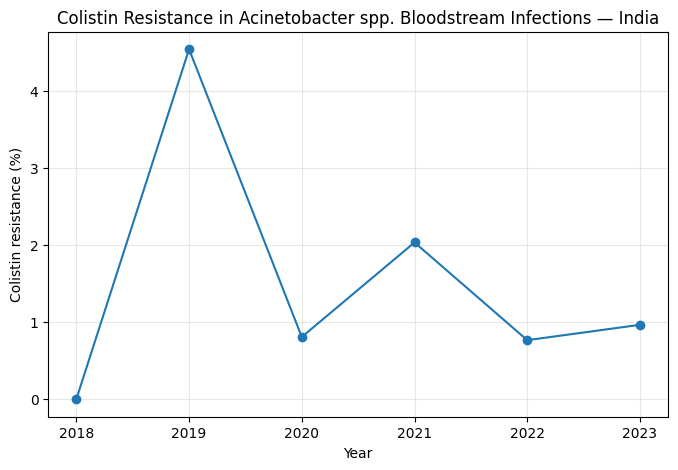

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    india_data["Year"],
    india_data["PercentResistant"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Colistin resistance (%)")
plt.title("Colistin Resistance in Acinetobacter spp. Bloodstream Infections — India")

plt.xticks(india_data["Year"])
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
global_ts = pd.read_csv(
    "/content/Time series of resistance to antibiotics (2018-2023)_All-BLOOD.csv",
    skiprows=7,
    nrows=6
)

global_ts[["Year", "Median", "Q1", "Q3"]]

,Year,Median,Q1,Q3
0,2018,1.270640,0.000000,4.599567
1,2019,2.210453,0.000000,7.702248
2,2020,2.665996,0.503356,7.643486
3,2021,2.303263,1.012883,6.737815
4,2022,3.244840,2.580658,8.042622
5,2023,3.863519,1.373210,9.164531


In [ ]:
comparison = india_data[["Year", "PercentResistant"]].merge(
    global_ts[["Year", "Median"]],
    on="Year"
)

comparison

,Year,PercentResistant,Median
0,2018,0.000000,1.270640
1,2019,4.545455,2.210453
2,2020,0.808625,2.665996
3,2021,2.036082,2.303263
4,2022,0.766902,3.244840
5,2023,0.966399,3.863519


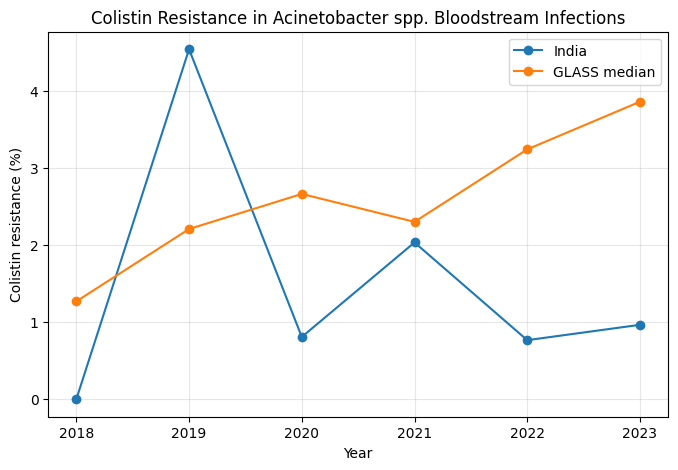

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison["Year"],
    comparison["PercentResistant"],
    marker="o",
    label="India"
)

plt.plot(
    comparison["Year"],
    comparison["Median"],
    marker="o",
    label="GLASS median"
)

plt.xlabel("Year")
plt.ylabel("Colistin resistance (%)")
plt.title("Colistin Resistance in Acinetobacter spp. Bloodstream Infections")
plt.xticks(comparison["Year"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
india_summary = india_data[
    ["Year", "InterpretableAST", "Resistant", "PercentResistant"]
].copy()

india_summary

,Year,InterpretableAST,Resistant,PercentResistant
2,2018,42,0,0.000000
13,2019,330,15,4.545455
24,2020,371,3,0.808625
35,2021,3880,79,2.036082
46,2022,4955,38,0.766902
57,2023,6726,65,0.966399


In [ ]:
summary_2023 = file_2023.iloc[:7].copy()

summary_2023

,Specimen,PathogenName,AntibioticName,Min,Q1,Median,Q3,Max,CTAsCount,TotalBCIsWithAST
0,Bloodstream,Acinetobacter spp.,Amikacin,0,10.843373494,44.206773619,70.476190476,94.418604651,77,43102
1,Bloodstream,Acinetobacter spp.,Colistin,0,0.978606393,3.851851852,8.26317716,47.540983607,46,15553
2,Bloodstream,Acinetobacter spp.,Doripenem,14.814814815,33.703703704,48.794642857,59.007513066,63.262195122,4,994
3,Bloodstream,Acinetobacter spp.,Gentamicin,0,27.698863636,54.435288415,67.289229751,96.875,83,44185
4,Bloodstream,Acinetobacter spp.,Imipenem,0,31.325301205,65.330188679,81.818181818,100,73,42540
5,Bloodstream,Acinetobacter spp.,Meropenem,0,23.138297872,60,76.349710443,98.742138365,79,43431
6,Bloodstream,Acinetobacter spp.,Minocycline,0.251730648,3.416856492,7.106598985,21.621621622,81.818181818,13,12864


In [ ]:
profile_2023 = summary_2023[
    ["AntibioticName", "Median", "Q1", "Q3"]
].copy()

profile_2023

,AntibioticName,Median,Q1,Q3
0,Amikacin,44.206773619,10.843373494,70.476190476
1,Colistin,3.851851852,0.978606393,8.26317716
2,Doripenem,48.794642857,33.703703704,59.007513066
3,Gentamicin,54.435288415,27.698863636,67.289229751
4,Imipenem,65.330188679,31.325301205,81.818181818
5,Meropenem,60,23.138297872,76.349710443
6,Minocycline,7.106598985,3.416856492,21.621621622


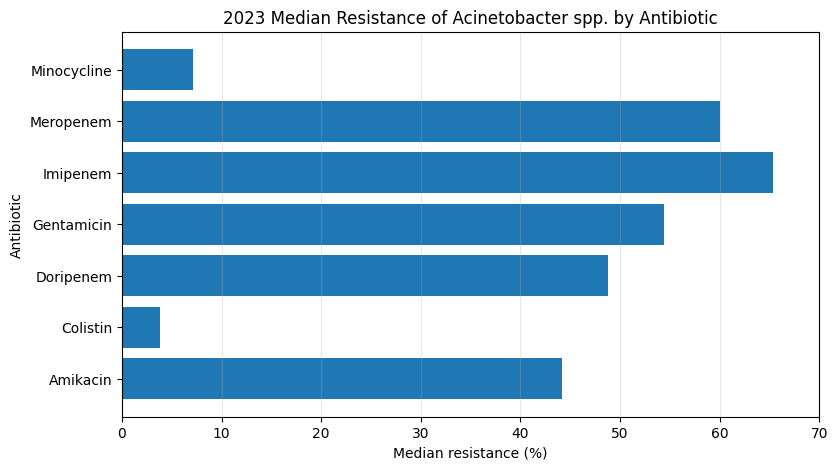

In [ ]:
plot_data = profile_2023.copy()

plot_data["Median"] = pd.to_numeric(plot_data["Median"])

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["AntibioticName"],
    plot_data["Median"]
)

plt.xlabel("Median resistance (%)")
plt.ylabel("Antibiotic")
plt.title("2023 Median Resistance of Acinetobacter spp. by Antibiotic")

plt.xlim(0, 70)
plt.grid(axis="x", alpha=0.3)

plt.show()